<a href="https://colab.research.google.com/github/ShiftorTheOrca/asah-capstone/blob/nevets/asah_fetch_a25_cs328.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Library**

In [ ]:
# Library Essential
import numpy as np
import pandas as pd
import os
import shutil
from google.colab import files
from datetime import datetime

# Library Pre-processing Data
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.decomposition import PCA

# Library Machine Learning
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

# Library Visualisasi Data
import plotly as py
import plotly.graph_objs as go
import seaborn as sns
import matplotlib.pyplot as plt


# **Load Dataset**

Load dataset yang dari Kaggle:
- Online Retail Dataset (UCI)
- Online Retail Dataset II (UCI)

In [ ]:
# Upload file .json untuk API key
files.upload()
print("API Key Received")

Saving kaggle.json to kaggle.json
API Key Received


In [ ]:
os.makedirs('/root/.kaggle', exist_ok=True)

# Download dataset dari Kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d viridianachow/online-retail-uci-dataset
!kaggle datasets download -d mashlyn/online-retail-ii-uci

Dataset URL: https://www.kaggle.com/datasets/viridianachow/online-retail-uci-dataset
License(s): unknown
  0% 0.00/7.15M [00:00<?, ?B/s]
100% 7.15M/7.15M [00:00<00:00, 920MB/s]
Dataset URL: https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci
License(s): CC0-1.0
  0% 0.00/14.5M [00:00<?, ?B/s]
100% 14.5M/14.5M [00:00<00:00, 1.24GB/s]


In [ ]:
!unzip "online-retail-uci-dataset.zip"
!unzip "online-retail-ii-uci.zip"

Archive:  online-retail-uci-dataset.zip
  inflating: Online Retail.csv       
Archive:  online-retail-ii-uci.zip
  inflating: online_retail_II.csv    


In [ ]:
# Simpan dataset dari csv ke DataFrame Pandas
df_1 = pd.read_csv('Online Retail.csv')
df_2 = pd.read_csv('online_retail_II.csv')

In [ ]:
df_1.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom


In [ ]:
df_2.head(3)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom


# **Exploratory Data Analysis**

Exploratory Data Analysis (EDA) untuk mencari dari pola data pembelian

In [ ]:
# Menyamakan nama kolom agar kedua DataFrame dapat digabung
column_names = ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'CustomerID', 'Country']
df_1.columns = df_2.columns = column_names

In [ ]:
# Gabung menjadi 1 DataFrame
df_all = pd.concat([df_1, df_2])
df_all.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


### Informasi Dataset

In [ ]:
# Tampilkan info dataset
df_all.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1609280 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1609280 non-null  object 
 1   StockCode    1609280 non-null  object 
 2   Description  1603444 non-null  object 
 3   Quantity     1609280 non-null  int64  
 4   InvoiceDate  1609280 non-null  object 
 5   Price        1609280 non-null  float64
 6   CustomerID   1231193 non-null  float64
 7   Country      1609280 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 110.5+ MB


In [ ]:
df_all.describe(include='all')

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
count,1609280,1609280,1603444,1.609280e+06,1609280,1.609280e+06,1.231193e+06,1609280
unique,53628,5305,5698,NaN,70895,NaN,NaN,43
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,2010-12-06 16:57:00,NaN,NaN,United Kingdom
freq,2228,8142,8287,NaN,1350,NaN,NaN,1476808
mean,NaN,NaN,NaN,9.808698e+00,NaN,4.636499e+00,1.531243e+04,NaN
std,NaN,NaN,NaN,1.892047e+02,NaN,1.152285e+02,1.702901e+03,NaN
min,NaN,NaN,NaN,-8.099500e+04,NaN,-5.359436e+04,1.234600e+04,NaN
25%,NaN,NaN,NaN,1.000000e+00,NaN,1.250000e+00,1.396900e+04,NaN
50%,NaN,NaN,NaN,3.000000e+00,NaN,2.100000e+00,1.522000e+04,NaN
75%,NaN,NaN,NaN,1.000000e+01,NaN,4.130000e+00,1.679500e+04,NaN


### Korelasi Antar Variabel

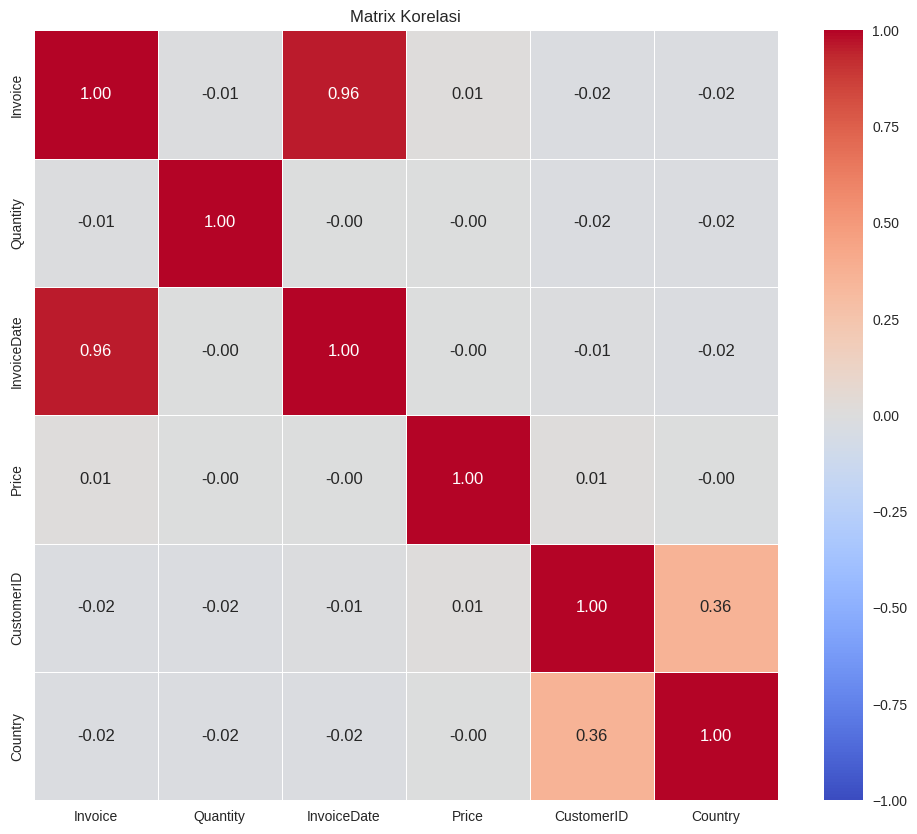

In [ ]:
# Encode variabel kategorikal yang relevan
label_encoder = LabelEncoder()
df_lencoder = df_all.drop(['StockCode', 'Description'], axis=1)

# Konversi tanggal ke format yang sesuai
df_lencoder['InvoiceDate'] = pd.to_datetime(df_lencoder['InvoiceDate'], format='mixed')
category_features = ['Invoice', 'CustomerID', 'Country']
for col in category_features:
  df_lencoder[col] = label_encoder.fit_transform(df_all[col])

plt.figure(figsize=(12, 10))
matrix_korelasi = df_lencoder.corr()

sns.heatmap(matrix_korelasi, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matrix Korelasi')
plt.show()

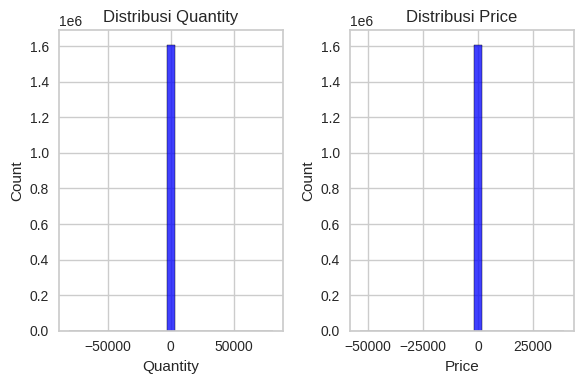

In [ ]:
column_display = ['Quantity', 'Price']
plt.figure(figsize=(6, 4))

for i, column in enumerate(column_display, 1):
  plt.subplot(1, 2, i)
  sns.histplot(df_all[column], bins=25, color='blue')
  plt.title(f'Distribusi {column}')
plt.tight_layout()
plt.show()

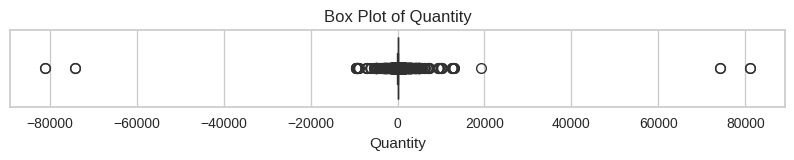

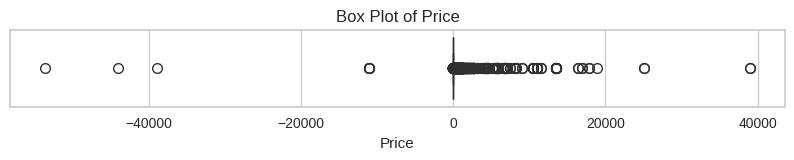

In [ ]:
numerik = ['Quantity', 'Price']
for feature in numerik:
  plt.figure(figsize=(10, 1))
  sns.boxplot(x=df_all[feature])
  plt.title(f'Box Plot of {feature}')
  plt.show()

# **Data Cleaning & Preprocessing**

### Data Cleaning

##### Hapus missing values dan data duplikat

In [ ]:
print("Data duplikat:", df_all.duplicated().sum())

print("Data hilang: ")
missing_values = df_all.isnull().sum()
missing_values[missing_values > 0]

Data duplikat: 39603
Data hilang: 


,0
Description,5836
CustomerID,378087


In [ ]:
# Hapus data duplikat
df_clean = df_all.drop_duplicates()

# Hapus data hilang
filter_custID = (df_clean['CustomerID'].notnull() & df_clean['Description'].notnull())
df_clean = df_clean[filter_custID]

In [ ]:
# Cek informasi dataset setelah cleaning
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1199489 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1199489 non-null  object 
 1   StockCode    1199489 non-null  object 
 2   Description  1199489 non-null  object 
 3   Quantity     1199489 non-null  int64  
 4   InvoiceDate  1199489 non-null  object 
 5   Price        1199489 non-null  float64
 6   CustomerID   1199489 non-null  float64
 7   Country      1199489 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 82.4+ MB


##### Hapus data negatif

In [ ]:
# Buat & apply filter untuk data negatif
filter_price = df_clean['Price'] >= 0
df_clean = df_clean[filter_price]
filter_quantity = df_clean['Quantity'] >= 0
df_clean = df_clean[filter_quantity]

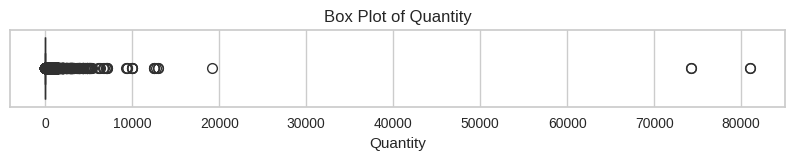

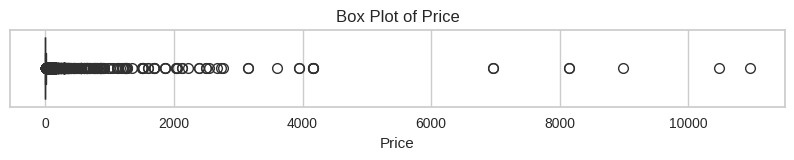

In [ ]:
column_display = ['Quantity', 'Price']
for feature in column_display:
  plt.figure(figsize=(10, 1))
  sns.boxplot(x=df_clean[feature])
  plt.title(f'Box Plot of {feature}')
  plt.show()

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1172227 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1172227 non-null  object 
 1   StockCode    1172227 non-null  object 
 2   Description  1172227 non-null  object 
 3   Quantity     1172227 non-null  int64  
 4   InvoiceDate  1172227 non-null  object 
 5   Price        1172227 non-null  float64
 6   CustomerID   1172227 non-null  float64
 7   Country      1172227 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 80.5+ MB


##### Hapus Outlier

In [ ]:
# Data numerik outlier dicari dan dibuang\n",
# Pemilihan field dilakukan manual karena CustomerID tidak termasuk numerik;\n",
# namun pada DataFrame dikategorikan sebagai numerik (float64)\n",
numerik = ['Quantity', 'Price']
print("Sebelum drop outlier:", df_clean.shape)
for col in numerik:
  # Cari kuantil 1 dan 3 setiap untuk mendapatkan batas bawah & batas atas\n",
  Q1 = df_clean[col].quantile(0.25)
  Q3 = df_clean[col].quantile(0.75)
  IQR = Q3 - Q1
  batas_bawah = Q1 - 1.5 * IQR
  batas_atas = Q3 + 1.5 * IQR
  # Outlier = data yang di nilainya di bawah batas bawah/di atas batas atas\n",
  outlier = df_clean[(df_clean[col] < batas_bawah) | (df_clean[col] > batas_atas)]

  print()
  print("Kolom", col, "memiliki batas bawah", batas_bawah, "dan batas atas", batas_atas)

  df_clean = df_clean.drop(outlier.index)
  print("Setelah drop outlier", col, ":", df_clean.shape)

Sebelum drop outlier: (1172227, 8)

Kolom Quantity memiliki batas bawah -13.0 dan batas atas 27.0
Setelah drop outlier Quantity : (1059578, 8)

Kolom Price memiliki batas bawah -2.5 dan batas atas 7.5
Setelah drop outlier Price : (922683, 8)


In [ ]:
df_clean.describe()

,Quantity,Price,CustomerID
count,922683.000000,922683.000000,922683.000000
mean,7.450475,2.246435,15338.591540
std,6.735117,1.588175,1699.695008
min,1.000000,0.000000,12346.000000
25%,2.000000,1.250000,13995.000000
50%,6.000000,1.650000,15288.000000
75%,12.000000,2.950000,16814.000000
max,27.000000,7.500000,18287.000000


### Preprocessing Data

In [ ]:
# Konversi format tanggal agar terstandarisasi
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'], format='mixed')

# Ubah CustomerID menjadi integer
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

In [ ]:
df_clean = df_clean.sort_values('InvoiceDate')
df_clean

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
...,...,...,...,...,...,...,...,...
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680,France
541894,581587,22631,CIRCUS PARADE LUNCH BOX,12,2011-12-09 12:50:00,1.95,12680,France


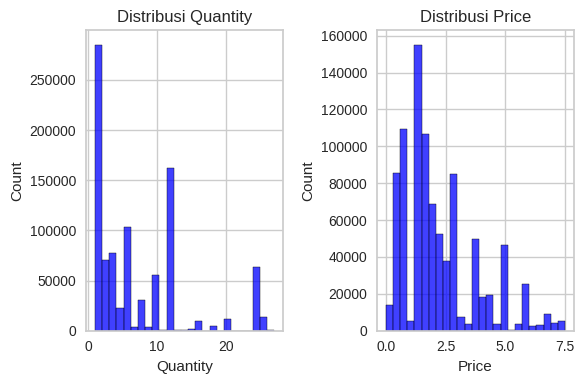

In [ ]:
column_display = ['Quantity', 'Price']
plt.figure(figsize=(6, 4))

for i, column in enumerate(column_display, 1):
  plt.subplot(1, 2, i)
  sns.histplot(df_clean[column], bins=25, color='blue')
  plt.title(f'Distribusi {column}')
plt.tight_layout()
plt.show()

# **Persiapan RFM**

Recency: Kapan terakhir seorang user melakukan transaksi

Frequency: Seberapa sering user melakukan transaksi

Monetary: Seberapa besar transaksi yang dilakukan user

### Pembuatan Variabel untuk RFM

In [ ]:
# Hitung total belanja setiap barang
df_clean['Total'] = df_clean['Quantity'] * df_clean['Price']
df_clean.head(3)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,Total
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085,United Kingdom,59.5
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


In [ ]:
# Asumsi data diambil pada saat entri data terakhir
tgl_pengambilan = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

# Mengelompokkan data berdasarkan customer dan buat kolom baru untuk R, F, dan M
df_rfm = df_clean.groupby('CustomerID').agg(
  Recency=('InvoiceDate', lambda x: (tgl_pengambilan - x.max()).days),
  Frequency=('Invoice', 'nunique'),
  Monetary=('Total', 'sum')
).reset_index()
df_rfm

,CustomerID,Recency,Frequency,Monetary
0,12346,529,10,350.36
1,12347,2,8,6441.44
2,12348,249,4,376.16
3,12349,19,3,3509.51
4,12350,310,1,588.80
...,...,...,...,...
5661,18283,4,22,4224.41
5662,18284,432,1,286.88
5663,18285,661,1,93.20
5664,18286,477,2,936.19


In [ ]:
df_rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,5666.000000,5666.000000,5666.000000,5666.000000
mean,15317.522767,200.385634,5.845041,2111.619079
std,1715.896251,208.801753,11.419343,5211.212828
min,12346.000000,1.000000,1.000000,0.000000
25%,13834.250000,26.000000,1.000000,308.105000
50%,15316.000000,95.000000,3.000000,827.675000
75%,16802.750000,379.000000,6.000000,2167.107500
max,18287.000000,739.000000,364.000000,241659.950000


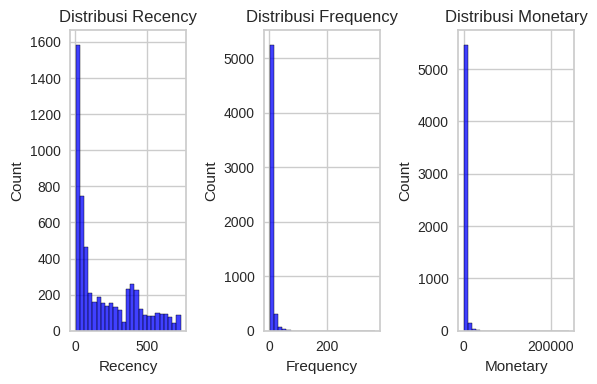

In [ ]:
column = ['Recency', 'Frequency', 'Monetary']
plt.figure(figsize=(6, 4))

for i, column in enumerate(column, 1):
  plt.subplot(1, 3, i)
  sns.histplot(df_rfm[column], bins=25, color='blue')
  plt.title(f'Distribusi {column}')
plt.tight_layout()
plt.show()

### Transformasi agar data lebih balanced

In [ ]:
# Transformasi logaritmik
df_rfm_log = df_rfm[['Recency', 'Frequency', 'Monetary']].apply(np.log1p, axis=1)
df_rfm_log.head()

,Recency,Frequency,Monetary
0,6.272877,2.397895,5.861811
1,1.098612,2.197225,8.770663
2,5.521461,1.609438,5.932670
3,2.995732,1.386294,8.163517
4,5.739793,0.693147,6.379783


In [ ]:
# Standarisasi data
scaler = MinMaxScaler()
rfm_minmax = scaler.fit_transform(df_rfm_log)

df_rfm_minmax = pd.DataFrame(rfm_minmax, columns=['Recency', 'Frequency', 'Monetary'])
df_rfm_minmax.head()

,Recency,Frequency,Monetary
0,0.943557,0.327411,0.472906
1,0.068566,0.288871,0.707580
2,0.816490,0.175981,0.478623
3,0.389378,0.133125,0.658598
4,0.853411,0.000000,0.514694


In [ ]:
df_rfm_minmax.describe()

,Recency,Frequency,Monetary
count,5666.000000,5666.000000,5666.000000
mean,0.635588,0.158734,0.540976
std,0.262803,0.150916,0.113758
min,0.000000,0.000000,0.000000
25%,0.440127,0.000000,0.462569
50%,0.654638,0.133125,0.542127
75%,0.887295,0.240604,0.619720
max,1.000000,1.000000,1.000000


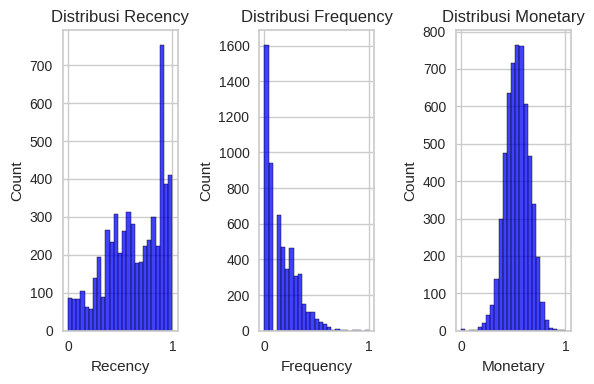

In [ ]:
column = ['Recency', 'Frequency', 'Monetary']
plt.figure(figsize=(6, 4))

for i, column in enumerate(column, 1):
  plt.subplot(1, 3, i)
  sns.histplot(df_rfm_minmax[column], bins=25, color='blue')
  plt.title(f'Distribusi {column}')
plt.tight_layout()
plt.show()

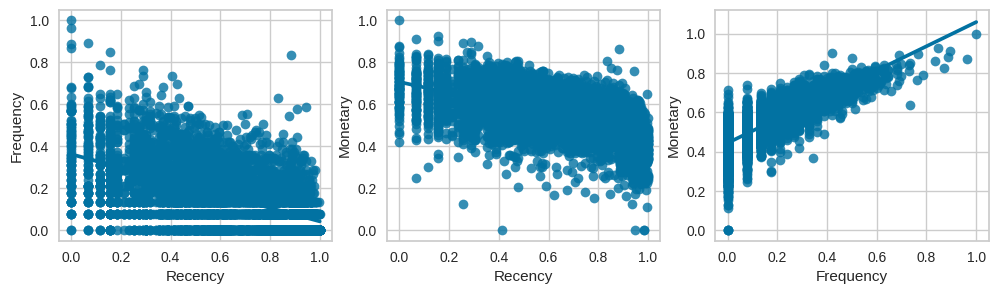

In [ ]:
plt.figure(1, figsize=(12, 3))

plt.subplot(1 , 3 , 1)
sns.regplot(x='Recency' , y='Frequency' , data=df_rfm_minmax)

plt.subplot(1 , 3 , 2)
sns.regplot(x='Recency' , y='Monetary' , data=df_rfm_minmax)

plt.subplot(1 , 3 , 3)
sns.regplot(x='Frequency' , y='Monetary' , data=df_rfm_minmax)

plt.show()

# **Clustering**

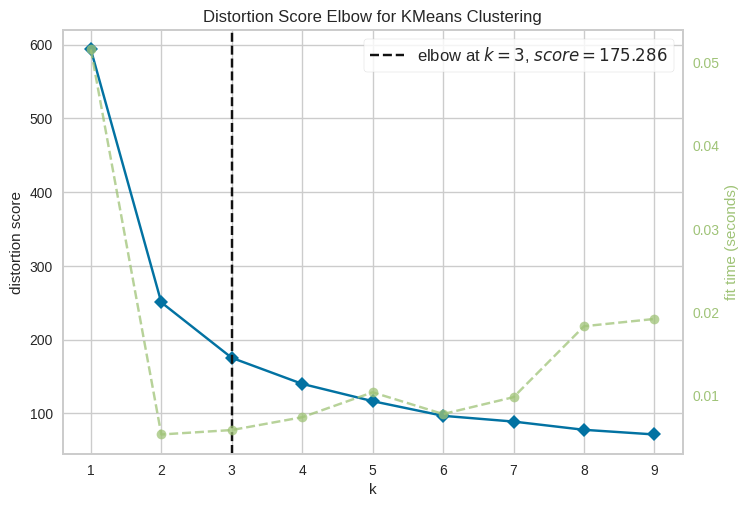

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
kmeans_elbow = KMeans()
visualizer = KElbowVisualizer(kmeans_elbow, k=(1, 10))
visualizer.fit(df_rfm_minmax)
visualizer.show()

### K-Means

In [ ]:
k_elbow = 3
kmeans = KMeans(n_clusters=k_elbow)
kmeans.fit(df_rfm_minmax)
labels = kmeans.labels_

# Catat label (cluster) setiap data
df_rfm['Cluster'] = labels
df_rfm_minmax['Cluster'] = labels

In [ ]:
# Analisis karakter cluster
cluster_analysis = df_rfm.groupby('Cluster').agg(
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Count=('CustomerID', 'count'),
    Percentage=('CustomerID', lambda x: (x.count() / len(df_rfm_minmax)) * 100)
).sort_values(by='Avg_Recency', ascending=False)

cluster_analysis


,Avg_Recency,Avg_Frequency,Avg_Monetary,Count,Percentage
Cluster,,,,,
1,402.209161,2.237130,530.279102,2467,43.540417
2,63.073194,4.817741,1745.186516,2063,36.410166
0,11.456866,15.545775,6211.193112,1136,20.049418


In [ ]:
ss_k = silhouette_score(df_rfm, df_rfm['Cluster'])
print("Silhouette Score K-Means =", ss_k)

ss_k_minmax = silhouette_score(df_rfm_minmax, df_rfm['Cluster'])
print("Silhouette Score K-Means (MinMax) =", ss_k_minmax)

Silhouette Score K-Means = 0.015521756169562419
Silhouette Score K-Means (MinMax) = 0.8050545454119131


In [ ]:
visual_3d = go.Scatter3d(
  x= df_rfm_minmax['Recency'],
  y= df_rfm_minmax['Frequency'],
  z= df_rfm_minmax['Monetary'],
  mode='markers',
    marker=dict(
      color = df_rfm_minmax['Cluster'],
      size= 20,
      line=dict(
        color= df_rfm_minmax['Cluster'],
        width= 12
      ),
      opacity=0.8
    )
)
data = [visual_3d]
layout = go.Layout(
  title= 'Clusters',
  scene = dict(
    xaxis = dict(title  = 'Recency'),
    yaxis = dict(title  = 'Frequency'),
    zaxis = dict(title  = 'Monetary')
  )
)
fig = go.Figure(data=data, layout=layout)
fig.show(renderer="colab")

In [ ]:
visual_3d = go.Scatter3d(
  x= df_rfm['Recency'],
  y= df_rfm['Frequency'],
  z= df_rfm['Monetary'],
  mode='markers',
    marker=dict(
      color = df_rfm['Cluster'],
      size= 20,
      line=dict(
        color= df_rfm['Cluster'],
        width= 12
      ),
      opacity=0.8
    )
)
data = [visual_3d]
layout = go.Layout(
  title= 'Clusters',
  scene = dict(
    xaxis = dict(title  = 'Recency'),
    yaxis = dict(title  = 'Frequency'),
    zaxis = dict(title  = 'Monetary')
  )
)
fig = go.Figure(data=data, layout=layout)
fig.show(renderer="colab")

### K-Means++

In [ ]:
k_elbow = 3
kmeans_pp = KMeans(n_clusters=k_elbow, init='k-means++')
kmeans_pp.fit(df_rfm_minmax)
labels = kmeans_pp.labels_

# Catat label (cluster) setiap data
df_rfm['Cluster_PP'] = labels
df_rfm_minmax['Cluster_PP'] = labels

In [ ]:
# Analisis karakter cluster
cluster_analysis_kpp = df_rfm.groupby('Cluster_PP').agg(
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Count=('CustomerID', 'count'),
    Percentage=('CustomerID', lambda x: (x.count() / len(df_rfm_minmax)) * 100)
).sort_values(by='Avg_Recency', ascending=False)

cluster_analysis_kpp


,Avg_Recency,Avg_Frequency,Avg_Monetary,Count,Percentage
Cluster_PP,,,,,
2,402.209161,2.237130,530.279102,2467,43.540417
0,63.073194,4.817741,1745.186516,2063,36.410166
1,11.456866,15.545775,6211.193112,1136,20.049418


In [ ]:
ss_kpp = silhouette_score(df_rfm, df_rfm['Cluster_PP'])
print("Silhouette Score K++ =", ss_kpp)

ss_kpp_minmax = silhouette_score(df_rfm_minmax, df_rfm['Cluster_PP'])
print("Silhouette Score K++ (MinMax) =", ss_kpp_minmax)

Silhouette Score K++ = 0.015522054260654776
Silhouette Score K++ (MinMax) = 0.8785443024423615


In [ ]:
visual_3d = go.Scatter3d(
  x= df_rfm_minmax['Recency'],
  y= df_rfm_minmax['Frequency'],
  z= df_rfm_minmax['Monetary'],
  mode='markers',
    marker=dict(
      color = df_rfm_minmax['Cluster_PP'],
      size= 20,
      line=dict(
        color= df_rfm_minmax['Cluster_PP'],
        width= 12
      ),
      opacity=0.8
    )
)
data = [visual_3d]
layout = go.Layout(
  title= 'Cluster_PP',
  scene = dict(
    xaxis = dict(title  = 'Recency'),
    yaxis = dict(title  = 'Frequency'),
    zaxis = dict(title  = 'Monetary')
  )
)
fig = go.Figure(data=data, layout=layout)
fig.show(renderer="colab")

In [ ]:
visual_3d = go.Scatter3d(
  x= df_rfm['Recency'],
  y= df_rfm['Frequency'],
  z= df_rfm['Monetary'],
  mode='markers',
    marker=dict(
    color = df_rfm['Cluster_PP'],
    size= 20,
    line=dict(
      color= df_rfm['Cluster_PP'],
      width= 12
    ),
    opacity=0.8
  )
)
data = [visual_3d]
layout = go.Layout(
  title= 'Cluster_PP',
  scene = dict(
    xaxis = dict(title  = 'Recency'),
    yaxis = dict(title  = 'Frequency'),
    zaxis = dict(title  = 'Monetary')
  )
)
fig = go.Figure(data=data, layout=layout)
fig.show(renderer="colab")

### DBSCAN

In [ ]:
dbscan = DBSCAN(eps=0.5, min_samples=2)

In [ ]:
dbscan.fit(df_rfm_minmax)
labels = dbscan.labels_

# Catat label (cluster) setiap data
df_rfm['Cluster_DBS'] = labels
df_rfm_minmax['Cluster_DBS'] = labels

In [ ]:
# Analisis karakter cluster
cluster_analysis_DBS = df_rfm.groupby('Cluster_DBS').agg(
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Count=('CustomerID', 'count'),
    Percentage=('CustomerID', lambda x: (x.count() / len(df_rfm_minmax)) * 100)
).sort_values(by='Avg_Recency', ascending=False)

cluster_analysis_DBS


,Avg_Recency,Avg_Frequency,Avg_Monetary,Count,Percentage
Cluster_DBS,,,,,
0,402.209161,2.237130,530.279102,2467,43.540417
2,63.073194,4.817741,1745.186516,2063,36.410166
1,11.456866,15.545775,6211.193112,1136,20.049418


In [ ]:
ss_dbs = silhouette_score(df_rfm, df_rfm['Cluster_DBS'])
print("Silhouette Score DBSCAN =", ss_dbs)

ss_dbs_minmax = silhouette_score(df_rfm_minmax, df_rfm['Cluster_DBS'])
print("Silhouette Score DBSCAN (MinMax) =", ss_dbs_minmax)

Silhouette Score DBSCAN = 0.015522352350230634
Silhouette Score DBSCAN (MinMax) = 0.894703481910254


In [ ]:
visual_3d = go.Scatter3d(
  x= df_rfm_minmax['Recency'],
  y= df_rfm_minmax['Frequency'],
  z= df_rfm_minmax['Monetary'],
  mode='markers',
    marker=dict(
      color = df_rfm_minmax['Cluster_DBS'],
      size= 20,
      line=dict(
        color= df_rfm_minmax['Cluster_DBS'],
        width= 12
      ),
      opacity=0.8
    )
)
data = [visual_3d]
layout = go.Layout(
  title= 'Cluster_DBSCAN',
  scene = dict(
    xaxis = dict(title  = 'Recency'),
    yaxis = dict(title  = 'Frequency'),
    zaxis = dict(title  = 'Monetary')
  )
)
fig = go.Figure(data=data, layout=layout)
fig.show(renderer="colab")

In [ ]:
visual_3d = go.Scatter3d(
  x= df_rfm['Recency'],
  y= df_rfm['Frequency'],
  z= df_rfm['Monetary'],
  mode='markers',
    marker=dict(
      color = df_rfm['Cluster_DBS'],
      size= 20,
      line=dict(
          color= df_rfm['Cluster_DBS'],
          width= 12
      ),
      opacity=0.8
    )
)
data = [visual_3d]
layout = go.Layout(
  title= 'Cluster_DBSCAN',
  scene = dict(
    xaxis = dict(title  = 'Recency'),
    yaxis = dict(title  = 'Frequency'),
    zaxis = dict(title  = 'Monetary')
  )
)
fig = go.Figure(data=data, layout=layout)
fig.show(renderer="colab")

In [ ]:
df_rfm

,CustomerID,Recency,Frequency,Monetary,Cluster,Cluster_PP,Cluster_DBS
0,12346,529,10,350.36,1,2,0
1,12347,2,8,6441.44,0,1,1
2,12348,249,4,376.16,1,2,0
3,12349,19,3,3509.51,2,0,2
4,12350,310,1,588.80,1,2,0
...,...,...,...,...,...,...,...
5661,18283,4,22,4224.41,0,1,1
5662,18284,432,1,286.88,1,2,0
5663,18285,661,1,93.20,1,2,0
5664,18286,477,2,936.19,1,2,0


#####PCA(dari ven pake kmeans)

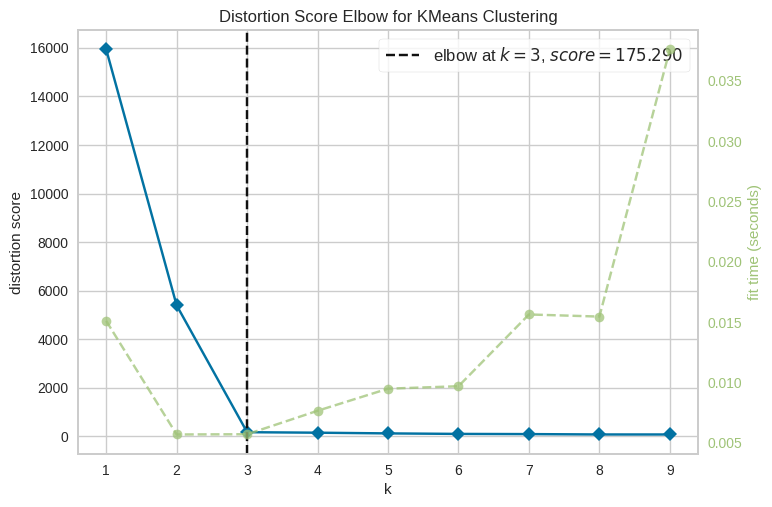

In [ ]:
# PCA untuk mengurangi dimensi atau menghasilkan fitur baru
pca = PCA(n_components=5)  # Menghasilkan fitur baru dari data asli
X_pca = pca.fit_transform(df_rfm_minmax)
visualizer = KElbowVisualizer(kmeans_elbow, k=(1, 10))
visualizer.fit(X_pca)
visualizer.show()
k_elbow=3
kmeans = KMeans(n_clusters=k_elbow)
kmeans.fit(X_pca)
labels = kmeans.labels_

# Catat label (cluster) setiap data
df_rfm['ClusterPCA'] = labels
df_rfm_minmax['ClusterPCA'] = labels



In [ ]:
silhouette_score(X_pca, labels)

np.float64(0.918970104737106)

In [ ]:
visual_3d = go.Scatter3d(
    x= df_rfm_minmax['Recency'],
    y= df_rfm_minmax['Frequency'],
    z= df_rfm_minmax['Monetary'],
    mode='markers',
     marker=dict(
        color = df_rfm_minmax['ClusterPCA'],
        size= 20,
        line=dict(
            color= df_rfm_minmax['ClusterPCA'],
            width= 12
        ),
        opacity=0.8
     )
)
data = [visual_3d]
layout = go.Layout(
    title= 'Cluster_PP',
    scene = dict(
            xaxis = dict(title  = 'Recency'),
            yaxis = dict(title  = 'Frequency'),
            zaxis = dict(title  = 'Monetary')
        )
)
fig = go.Figure(data=data, layout=layout)
fig.show(renderer="colab")

In [ ]:
visual_3d = go.Scatter3d(
    x= df_rfm['Recency'],
    y= df_rfm['Frequency'],
    z= df_rfm['Monetary'],
    mode='markers',
     marker=dict(
        color = df_rfm['ClusterPCA'],
        size= 20,
        line=dict(
            color= df_rfm['ClusterPCA'],
            width= 12
        ),
        opacity=0.8
     )
)
data = [visual_3d]
layout = go.Layout(
    title= 'Cluster_PP',
    scene = dict(
            xaxis = dict(title  = 'Recency'),
            yaxis = dict(title  = 'Frequency'),
            zaxis = dict(title  = 'Monetary')
        )
)
fig = go.Figure(data=data, layout=layout)
fig.show(renderer="colab")

In [ ]:
#coba pake dbscan
dbscan.fit(X_pca)
labels = dbscan.labels_

# Catat label (cluster) setiap data
df_rfm['Cluster_DBS_pca'] = labels
df_rfm_minmax['Cluster_DBS_pca'] = labels

In [ ]:
# Analisis karakter cluster df_rfm
cluster_analysis_DBS = df_rfm.groupby('Cluster_DBS_pca').agg(
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Count=('CustomerID', 'count'),
    Percentage=('CustomerID', lambda x: (x.count() / len(df_rfm_minmax)) * 100)
).sort_values(by='Avg_Recency', ascending=False)

cluster_analysis_DBS

,Avg_Recency,Avg_Frequency,Avg_Monetary,Count,Percentage
Cluster_DBS_pca,,,,,
0,402.209161,2.237130,530.279102,2467,43.540417
2,63.073194,4.817741,1745.186516,2063,36.410166
1,11.456866,15.545775,6211.193112,1136,20.049418


In [ ]:
# Analisis karakter cluster df_rfm_minmax
cluster_analysis_DBS = df_rfm_minmax.groupby('Cluster_DBS_pca').agg(
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
).sort_values(by='Avg_Recency', ascending=False)

cluster_analysis_DBS

,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster_DBS_pca,,,
0,0.882055,0.069473,0.463894
2,0.549648,0.165707,0.566035
1,0.256417,0.339919,0.662865


In [ ]:
ss_dbs = silhouette_score(df_rfm, df_rfm['Cluster_DBS'])
print("Silhouette Score DBSCAN =", ss_dbs)

ss_dbs_minmax = silhouette_score(df_rfm_minmax, df_rfm['Cluster_DBS'])
print("Silhouette Score DBSCAN (MinMax) =", ss_dbs_minmax)

Silhouette Score DBSCAN = 0.01552274377243852
Silhouette Score DBSCAN (MinMax) = 0.917620136415586


In [ ]:
visual_3d = go.Scatter3d(
  x= df_rfm_minmax['Recency'],
  y= df_rfm_minmax['Frequency'],
  z= df_rfm_minmax['Monetary'],
  mode='markers',
    marker=dict(
      color = df_rfm_minmax['Cluster_DBS_pca'],
      size= 20,
      line=dict(
        color= df_rfm_minmax['Cluster_DBS_pca'],
        width= 12
      ),
      opacity=0.8
    )
)
data = [visual_3d]
layout = go.Layout(
  title= 'Cluster_DBSCAN',
  scene = dict(
    xaxis = dict(title  = 'Recency'),
    yaxis = dict(title  = 'Frequency'),
    zaxis = dict(title  = 'Monetary')
  )
)
fig = go.Figure(data=data, layout=layout)
fig.show(renderer="colab")

In [ ]:
visual_3d = go.Scatter3d(
  x= df_rfm['Recency'],
  y= df_rfm['Frequency'],
  z= df_rfm['Monetary'],
  mode='markers',
    marker=dict(
      color = df_rfm['Cluster_DBS_pca'],
      size= 20,
      line=dict(
        color= df_rfm['Cluster_DBS_pca'],
        width= 12
      ),
      opacity=0.8
    )
)
data = [visual_3d]
layout = go.Layout(
  title= 'Cluster_DBSCAN',
  scene = dict(
    xaxis = dict(title  = 'Recency'),
    yaxis = dict(title  = 'Frequency'),
    zaxis = dict(title  = 'Monetary')
  )
)
fig = go.Figure(data=data, layout=layout)
fig.show(renderer="colab")

In [ ]:
df_rfm_minmax.head(30)

,Recency,Frequency,Monetary,Cluster,Cluster_PP,Cluster_DBS,ClusterPCA,Cluster_DBS_pca
0,0.943557,0.327411,0.472906,1,2,0,1,0
1,0.068566,0.288871,0.707580,0,1,1,2,1
2,0.816490,0.175981,0.478623,1,2,0,1,0
3,0.389378,0.133125,0.658598,2,0,2,0,2
4,0.853411,0.000000,0.514694,1,2,0,1,0
5,0.885506,0.000000,0.451292,1,2,0,1,0
6,0.493408,0.309106,0.628947,2,0,2,0,2
7,0.782931,0.077873,0.478666,1,2,0,1,0
8,0.804581,0.000000,0.572898,1,2,0,1,0
9,0.790985,0.077873,0.534830,1,2,0,1,0


In [ ]:
df_rfm.describe()

,CustomerID,Recency,Frequency,Monetary,Cluster,Cluster_PP,Cluster_DBS,ClusterPCA,Cluster_DBS_pca
count,5666.000000,5666.000000,5666.000000,5666.000000,5666.000000,5666.000000,5666.000000,5666.000000,5666.000000
mean,15317.522767,200.385634,5.845041,2111.619079,1.163607,1.071303,0.928697,0.836393,0.928697
std,1715.896251,208.801753,11.419343,5211.212828,0.733433,0.891382,0.891382,0.733433,0.891382
min,12346.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,13834.250000,26.000000,1.000000,308.105000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,15316.000000,95.000000,3.000000,827.675000,1.000000,1.000000,1.000000,1.000000,1.000000
75%,16802.750000,379.000000,6.000000,2167.107500,2.000000,2.000000,2.000000,1.000000,2.000000
max,18287.000000,739.000000,364.000000,241659.950000,2.000000,2.000000,2.000000,2.000000,2.000000
